# Random functions and Gaussian emulators

*If you haven't read the [Getting Started tutorial](../tutorials/getting_started.ipynb)
or the [broadcasting notebook](03_broadcasting.ipynb), read those first.*

A **random function** in ProbPipe is a distribution over
functions. `GaussianRandomFunction` is the core abstraction for
models that produce Gaussian predictive distributions at any set
of inputs — and by subclassing it you can build **emulators**:
fast surrogates for expensive models that carry calibrated
uncertainty.

This notebook walks through:

1. The type hierarchy (`RandomFunction` / `ArrayRandomFunction`
   / `GaussianRandomFunction` / `LinearBasisFunction`).
2. Building a custom `GaussianRandomFunction` (GP with an RBF
   kernel).
3. Shape semantics: `joint_inputs=` / `joint_outputs=` modes.
4. Algebraic operations: `A @ grf + b` gives a new
   `GaussianRandomFunction` with analytically correct moments.
5. Function sampling: draw a single realization and evaluate
   it at arbitrary inputs.
6. Fitting a `LinearBasisFunction` to observed data.
7. GP emulation: drop training data into a GP and use it as a
   fast surrogate.
8. Synthetic likelihoods: Gaussian approximations for
   simulation-based inference.
9. Provenance tracking.
10. Workflow-function broadcasting through random-function
    outputs.


In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from probpipe import (
    Distribution, RandomFunction, ArrayRandomFunction, GaussianRandomFunction,
    LinearBasisFunction, MultivariateNormal, Normal,
    Provenance, provenance_ancestors, set_return_approx_dist,
    expectation, log_prob, mean, sample, variance,
)

# For cleaner output in this notebook, return plain arrays from expectations.
set_return_approx_dist(False)

## 1. The Type Hierarchy

Every random function is a `Distribution`.  The hierarchy is:

```
Distribution[T]
  └── RandomFunction[X, Y]           # T = Callable; __call__ is abstract
        └── ArrayRandomFunction       # X = Array, Y = Array; shape contract
              └── GaussianRandomFunction  # Gaussian predictive distributions
                    └── LinearBasisFunction
```

`GaussianRandomFunction` supports algebraic operations (`A @ grf`, `grf + b`,
`alpha * grf`, `grf1 + grf2`) that produce new `GaussianRandomFunction`
objects with analytically correct moments.

`RandomFunction` sits alongside `NumericRecordDistribution` and
`ProductDistribution` in the distribution hierarchy — it is a peer, not a
replacement.

## 2. Shape Semantics (`ArrayRandomFunction`)

For array-valued random functions, calling the object with input `X` of
shape `(*extra_batch, n, *input_shape)` returns a `DistributionArray`
whose outer `batch_shape` covers axes that are **independent** across
cells and whose per-cell `event_shape` covers axes that are **jointly
modeled**:

| `joint_inputs` | `joint_outputs` | Cell type     | Outer `batch_shape`                | Cell `event_shape`     |
|:--------------:|:---------------:|:-------------:|:----------------------------------:|:----------------------:|
| False          | False           | `Normal`      | `(*extra_batch, n, *output_shape)` | `()`                   |
| True           | False           | `MVN`         | `(*extra_batch, *output_shape)`    | `(n,)`                 |
| False          | True            | `MVN`         | `(*extra_batch, n)`                | `output_shape`         |
| True           | True            | `MVN`         | `(*extra_batch,)`                  | `(n, *output_shape)`   |

In all modes the total shape of a sample is invariant:
`(*sample_shape, *extra_batch, n, *output_shape)`. The flags only control
which axes are jointly modelled (event) versus independent (batch).

## 3. Building a Custom `GaussianRandomFunction`

The simplest way to create a random function is to subclass
`GaussianRandomFunction` and implement `predict_mean`, `predict_variance`,
and (optionally) `predict_covariance`.

Below we build a zero-mean GP prior with a squared-exponential (RBF) kernel.
Because the GP provides a full covariance matrix across input points, we set
`supports_joint_inputs = True`.

In [2]:
def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """Squared-exponential (RBF) kernel."""
    sq_dist = jnp.sum((X1[:, None, :] - X2[None, :, :]) ** 2, axis=-1)
    return variance * jnp.exp(-0.5 * sq_dist / lengthscale ** 2)


class ToyGP(GaussianRandomFunction):
    """Zero-mean GP with an RBF kernel."""

    supports_joint_inputs = True

    def __init__(self, lengthscale=1.0, variance=1.0, noise=0.01):
        super().__init__(input_shape=(1,), output_shape=())
        self._ls = lengthscale
        self._var = variance
        self._noise = noise

    def predict_mean(self, X):
        extra_batch, n = self._parse_X(X)
        return jnp.zeros((*extra_batch, n))

    def predict_variance(self, X):
        extra_batch, n = self._parse_X(X)
        return jnp.full((*extra_batch, n), self._var)

    def predict_covariance(self, X, *, joint_inputs=False, joint_outputs=False):
        if not joint_inputs:
            raise NotImplementedError("Use predict_variance for marginals.")
        K = rbf_kernel(X, X, self._ls, self._var)
        return K + self._noise * jnp.eye(K.shape[-1])


gp = ToyGP(lengthscale=0.3, variance=1.0, noise=1e-4)
print(gp)
print(f"  isinstance(gp, Distribution): {isinstance(gp, Distribution)}")
print(f"  isinstance(gp, RandomFunction): {isinstance(gp, RandomFunction)}")

ToyGP(input_shape=(1,), output_shape=())
  isinstance(gp, Distribution): True
  isinstance(gp, RandomFunction): True


### 3.1 Marginal predictions (default mode)

Calling the GP with `n` input points returns a batch of `n` independent
`Normal` distributions — one per input point.

Type:        DistributionArray
batch_shape: (50,)
event_shape: ()


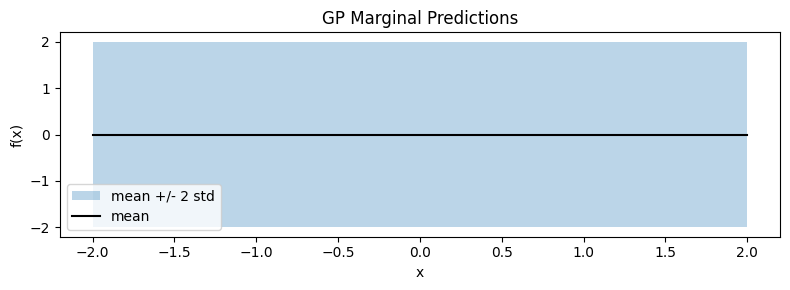

In [3]:
X_test = jnp.linspace(-2, 2, 50).reshape(-1, 1)

# Default: joint_inputs=False, joint_outputs=False
marginal = gp(X_test)

print(f"Type:        {type(marginal).__name__}")
print(f"batch_shape: {marginal.batch_shape}")
print(f"event_shape: {marginal.event_shape}")

# Plot marginal mean +/- 2 std
mu = jnp.asarray(mean(marginal))
std = jnp.sqrt(jnp.asarray(variance(marginal)))

fig, ax = plt.subplots(figsize=(8, 3))
ax.fill_between(X_test[:, 0], mu - 2 * std, mu + 2 * std, alpha=0.3, label="mean +/- 2 std")
ax.plot(X_test[:, 0], mu, "k-", lw=1.5, label="mean")
ax.set(xlabel="x", ylabel="f(x)", title="GP Marginal Predictions")
ax.legend()
plt.tight_layout()
plt.show()

### 3.2 Joint predictions (`joint_inputs=True`)

With `joint_inputs=True`, the GP returns a 0-d `DistributionArray`
wrapping a single `MultivariateNormal` whose event dimension spans
all `n` input points. Ops like `sample` / `mean` / `log_prob` treat
a 0-d DA transparently as that single cell, so we can draw
*correlated* samples (smooth function trajectories) directly.

Type:        DistributionArray
batch_shape: ()
event_shape: (50,)


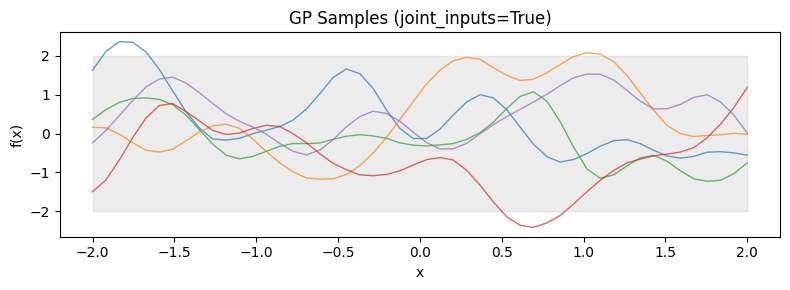

In [4]:
joint = gp(X_test, joint_inputs=True)

print(f"Type:        {type(joint).__name__}")
print(f"batch_shape: {joint.batch_shape}")
print(f"event_shape: {joint.event_shape}")

# Draw correlated samples (smooth trajectories). joint is a 0-d
# DistributionArray; sample() auto-unwraps to the single MVN cell.
trajectories = jnp.asarray(sample(joint, sample_shape=(5,)))  # (5, 50)

fig, ax = plt.subplots(figsize=(8, 3))
for i in range(5):
    ax.plot(X_test[:, 0], trajectories[i], alpha=0.7, lw=1)
ax.fill_between(X_test[:, 0], mu - 2 * std, mu + 2 * std, alpha=0.15, color="gray")
ax.set(xlabel="x", ylabel="f(x)", title="GP Samples (joint_inputs=True)")
plt.tight_layout(); plt.show()

### 3.3 Expectations on predictive distributions

The distribution returned by a random function is a standard ProbPipe
distribution.  All the usual operations work — `mean()`, `variance()`,
`sample()`, `expectation()`, `log_prob()`.

In [5]:
# Evaluate at a single input point
x_star = jnp.array([[0.5]])
pred = gp(x_star)

print(f"Predictive distribution at x=0.5: {type(pred).__name__}")
print(f"  mean:     {float(jnp.asarray(mean(pred)).squeeze()):.4f}")
print(f"  variance: {float(jnp.asarray(variance(pred)).squeeze()):.4f}")

# Compute E[sin(f(x*))] under the predictive distribution
E_sin = expectation(pred, jnp.sin, return_dist=False)
print(f"  E[sin(f)]: {float(jnp.asarray(E_sin).squeeze()):.4f}")

# Log-density at the mean
print(f"  log p(0): {float(jnp.asarray(log_prob(pred, jnp.array([0.0]))).squeeze()):.4f}")

Predictive distribution at x=0.5: DistributionArray
  mean:     0.0000
  variance: 1.0000


  E[sin(f)]: -0.0365
  log p(0): -0.9189


## 4. `LinearBasisFunction`

`LinearBasisFunction` is a concrete `GaussianRandomFunction` implementing
the model:

$$f(x) = a + \Phi(x)\, w, \qquad w \sim \mathcal{N}(m, C)$$

where $\Phi(x)$ is a user-supplied **feature map** and $w$ is a Gaussian
weight vector.  Because the model is linear in $w$, the predictive
distribution at any finite set of inputs is Gaussian with analytically
available mean, variance, and covariance.

This class also supports **function sampling**: since a function realization
is determined by a finite weight vector, `sample()` returns a callable that
evaluates the linear model at arbitrary inputs using a single weight draw.

In [6]:
def polynomial_features(X, degree=5):
    """Feature map: [1, x, x^2, ..., x^degree] for scalar input."""
    x = X[..., 0]  # (*extra_batch, n)
    return jnp.stack([x ** k for k in range(degree + 1)], axis=-1)


# Weight distribution: 6 basis functions with small prior uncertainty
d_w = 6
w_mean = jnp.zeros(d_w)
w_cov = 0.5 * jnp.eye(d_w)
weights = MultivariateNormal(loc=w_mean, cov=w_cov, name="auto_d1")

lbf = LinearBasisFunction(
    feature_map=polynomial_features,
    weights=weights,
    input_shape=(1,),
)

print(lbf)
print(f"  supports_joint_inputs:  {lbf.supports_joint_inputs}")
print(f"  supports_joint_outputs: {lbf.supports_joint_outputs}")

LinearBasisFunction(input_shape=(1,), output_shape=())
  supports_joint_inputs:  True
  supports_joint_outputs: False


### 4.1 Predictive distributions and sampling

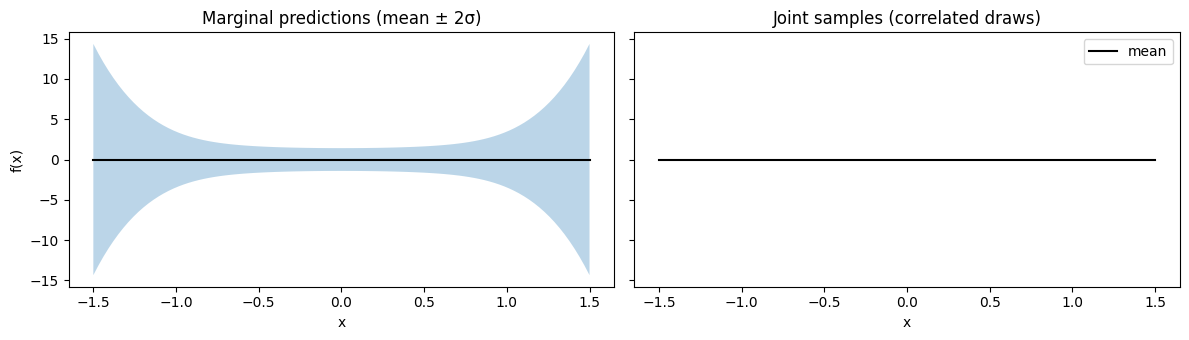

In [7]:
X_plot = jnp.linspace(-1.5, 1.5, 100).reshape(-1, 1)

# Marginal predictions
pred = lbf(X_plot)
mu = jnp.asarray(mean(pred))
sigma = jnp.sqrt(jnp.asarray(variance(pred)))

# Joint predictions for correlated samples (joint_pred is a 0-d
# DistributionArray; sample() auto-unwraps to the single MVN cell).
joint_pred = lbf(X_plot, joint_inputs=True)
joint_samples = jnp.asarray(sample(joint_pred, sample_shape=(8,)))  # (8, 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)

ax = axes[0]
ax.fill_between(X_plot[:, 0], mu - 2*sigma, mu + 2*sigma, alpha=0.3)
ax.plot(X_plot[:, 0], mu, "k-", lw=1.5)
ax.set(xlabel="x", ylabel="f(x)", title="Marginal predictions (mean ± 2σ)")

ax = axes[1]
for i in range(8):
    ax.plot(X_plot[:, 0], joint_samples[i], alpha=0.6, lw=1)
ax.plot(X_plot[:, 0], mu, "k-", lw=1.5, label="mean")
ax.set(xlabel="x", title="Joint samples (correlated draws)")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

### 4.2 Function sampling (`sample`)

Because `LinearBasisFunction` is a finite-dimensional model (parameterized
by a weight vector), it supports **function sampling** — `sample()` returns
a *callable* that evaluates the sampled function at arbitrary inputs.

This is fundamentally different from sampling the predictive distribution
at fixed inputs: here we get a single coherent function that can be queried
at any new point.

In [8]:
# Draw a single function realization
f_single = sample(lbf)

print(f"Type of sample: {type(f_single)}")
print(f"Callable?       {callable(f_single)}")

# Evaluate the sampled function at different input sets
y1 = f_single(X_plot)
y2 = f_single(jnp.array([[0.0], [1.0], [-1.0]]))

print(f"\nEvaluated at 100 points: shape {y1.shape}")
print(f"Evaluated at 3 points:   shape {y2.shape}")

# The same function evaluated twice at the same input gives the same output
y1_again = f_single(X_plot)
print(f"\nConsistent? {jnp.allclose(y1, y1_again)}")

# Draw multiple function realizations at once
f_batch = sample(lbf, sample_shape=(5,))
y_batch = f_batch(X_plot)
print(f"\nBatch of 5 functions, each evaluated at 100 points: shape {y_batch.shape}")

Type of sample: <class 'probpipe.core.record.Record'>
Callable?       True

Evaluated at 100 points: shape (100,)
Evaluated at 3 points:   shape (3,)



Consistent? True



Batch of 5 functions, each evaluated at 100 points: shape (5, 100)


## 5. Gaussian Algebra

Linear transformations of Gaussian random variables are Gaussian.
`GaussianRandomFunction` exploits this by defining algebraic operators
that produce new `GaussianRandomFunction` objects with the correct
mean, variance, and covariance propagation.

| Operation | Syntax | Result |
|:----------|:-------|:-------|
| Linear map | `A @ grf` | Output projected by matrix $A$ (requires 1-D `output_shape`) |
| Bias shift | `grf + b` | Mean shifted by constant $b$ |
| Scalar scale | `alpha * grf` | Mean scaled by $\alpha$, variance by $\alpha^2$ |
| Independent sum | `grf1 + grf2` | Sum of two **independent** GRFs |

These compose naturally: `A @ grf + b` is an affine transform.

In [9]:
# Build a base function that outputs a 3-D latent vector at each input.
def latent_features(X):
    """Multi-output feature map: scalar input -> (3, 4) features per point."""
    x = X[..., 0]
    feats_1d = jnp.stack([jnp.ones_like(x), x, x**2, x**3], axis=-1)
    return jnp.stack([feats_1d, 0.5 * feats_1d, 0.3 * feats_1d], axis=-2)

latent_weights = MultivariateNormal(loc=jnp.zeros(4), cov=jnp.eye(4), name="auto_d2")
base_fn = LinearBasisFunction(
    feature_map=latent_features,
    weights=latent_weights,
    input_shape=(1,),
    output_shape=(3,),
)

# --- Linear map: project 3-D latent to 2-D observation space ---
A = jnp.array([[1.0, 0.5, 0.0],
               [0.0, 0.3, 1.0]])
projected = A @ base_fn
print(f"A @ base_fn:  output_shape={projected.output_shape}")

# --- Bias shift ---
shifted = projected + jnp.array([0.1, -0.2])
print(f"+ bias:       output_shape={shifted.output_shape}")

# --- Affine shorthand: A @ grf + b ---
affine = A @ base_fn + jnp.array([0.1, -0.2])

# --- Scalar scale ---
scaled = 2.0 * base_fn
print(f"2 * base_fn:  output_shape={scaled.output_shape}")

# All results are GaussianRandomFunctions
print(f"\nisinstance checks:")
print(f"  A @ grf:       {isinstance(projected, GaussianRandomFunction)}")
print(f"  grf + b:       {isinstance(shifted, GaussianRandomFunction)}")
print(f"  alpha * grf:   {isinstance(scaled, GaussianRandomFunction)}")

A @ base_fn:  output_shape=(2,)
+ bias:       output_shape=(2,)
2 * base_fn:  output_shape=(3,)

isinstance checks:
  A @ grf:       True
  grf + b:       True
  alpha * grf:   True


Plot the affine-transformed outputs against the input. Mean and ±2σ bands come straight from `mean` / `variance` on the `pred` distribution:

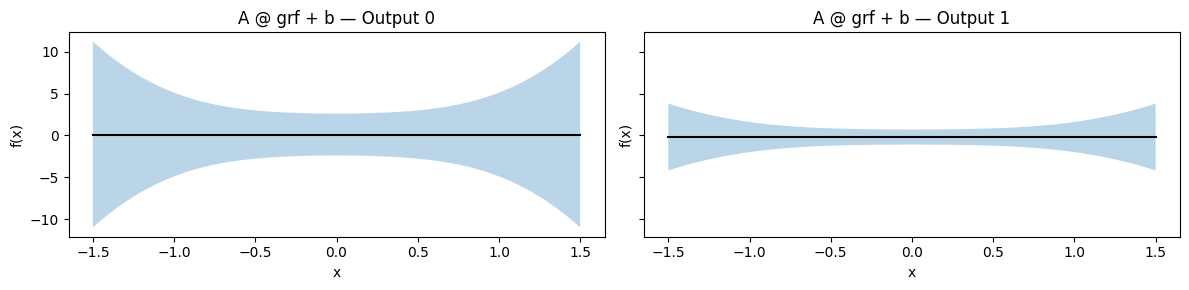

In [10]:
# Visualize the affine transform: A @ base_fn + bias
X_plot = jnp.linspace(-1.5, 1.5, 60).reshape(-1, 1)
pred = affine(X_plot)

mu = jnp.asarray(mean(pred))
std = jnp.sqrt(jnp.asarray(variance(pred)))

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
for i, label in enumerate(["Output 0", "Output 1"]):
    ax = axes[i]
    ax.fill_between(X_plot[:, 0], mu[:, i] - 2*std[:, i],
                     mu[:, i] + 2*std[:, i], alpha=0.3)
    ax.plot(X_plot[:, 0], mu[:, i], "k-", lw=1.5)
    ax.set(xlabel="x", ylabel="f(x)", title=f"A @ grf + b — {label}")
plt.tight_layout()

## 6. Fitting a Model to Data

Any `GaussianRandomFunction` subclass can implement a `fit()` method
to incorporate training data. Below we extend `LinearBasisFunction`
with a `fit()` method that performs Bayesian linear regression,
updating the weight distribution analytically.

isinstance(model, LinearBasisFunction): True
Training points: 15


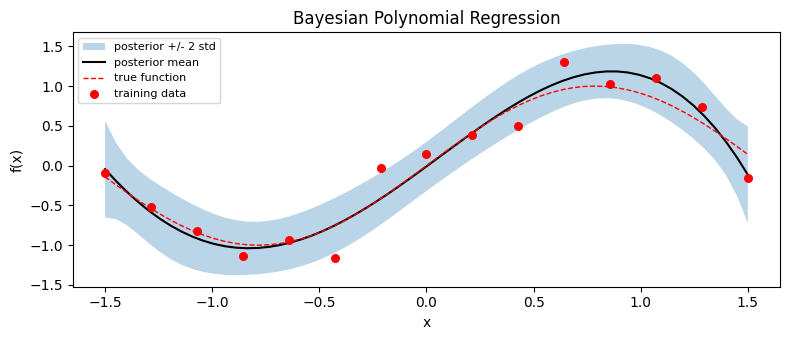

In [11]:
class FittedPolynomial(LinearBasisFunction):
    """A LinearBasisFunction that can be fit to data via least-squares."""

    def __init__(self, degree=3):
        self._degree = degree
        d_w = degree + 1
        # Start with a vague prior
        super().__init__(
            feature_map=lambda X: polynomial_features(X, degree=degree),
            weights=MultivariateNormal(
                loc=jnp.zeros(d_w),
                cov=100.0 * jnp.eye(d_w), name="auto_d1"
            ),
            input_shape=(1,),
        )
        self._X_train = None
        self._Y_train = None

    def fit(self, X, Y):
        """Bayesian linear regression: update weights given data."""
        X, Y = jnp.asarray(X), jnp.asarray(Y)
        self._X_train = X
        self._Y_train = Y

        phi = self._feature_map(X)  # (n, d_w)
        noise_var = 0.1

        # Posterior: w | data ~ N(m_post, C_post)
        prior_prec = jnp.linalg.inv(self._w_cov)
        C_post = jnp.linalg.inv(prior_prec + phi.T @ phi / noise_var)
        m_post = C_post @ (prior_prec @ self._w_mean + phi.T @ Y / noise_var)

        self._w_mean = m_post
        self._w_cov = C_post
        self._weights = MultivariateNormal(loc=m_post, cov=C_post, name="auto_d3")


# Generate noisy data from a true function
true_fn = lambda x: jnp.sin(2 * x)
X_train = jnp.linspace(-1.5, 1.5, 15).reshape(-1, 1)
Y_train = true_fn(X_train[:, 0]) + 0.2 * jax.random.normal(jax.random.PRNGKey(12), shape=(15,))

# Fit the model
model = FittedPolynomial(degree=5)
model.fit(X_train, Y_train)

print(f"isinstance(model, LinearBasisFunction): {isinstance(model, LinearBasisFunction)}")
print(f"Training points: {model._X_train.shape[0]}")

# Predict
pred_fit = model(X_plot)
mu_fit = jnp.asarray(mean(pred_fit))
sigma_fit = jnp.sqrt(jnp.asarray(variance(pred_fit)))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.fill_between(X_plot[:, 0], mu_fit - 2*sigma_fit, mu_fit + 2*sigma_fit, alpha=0.3, label="posterior +/- 2 std")
ax.plot(X_plot[:, 0], mu_fit, "k-", lw=1.5, label="posterior mean")
ax.plot(X_plot[:, 0], true_fn(X_plot[:, 0]), "r--", lw=1, label="true function")
ax.scatter(X_train[:, 0], Y_train, c="red", s=30, zorder=5, label="training data")
ax.set(xlabel="x", ylabel="f(x)", title="Bayesian Polynomial Regression")
ax.legend(fontsize=8)
plt.tight_layout()

## 7. GP Emulator: fitting a GP to training data


Any `GaussianRandomFunction` subclass can store training data and
implement GP posterior equations. Below we build a GP that conditions
on observed data via standard posterior formulas.

In [12]:
class GPEmulator(GaussianRandomFunction):
    """GP with RBF kernel that can be fit to data."""

    supports_joint_inputs = True

    def __init__(self, lengthscale=1.0, variance=1.0, noise=0.01):
        super().__init__(input_shape=(1,), output_shape=())
        self._ls = lengthscale
        self._var = variance
        self._noise = noise
        self._X_train = None
        self._Y_train = None
        self._K_inv = None

    def fit(self, X, Y):
        self._X_train = jnp.asarray(X)
        self._Y_train = jnp.asarray(Y)
        K = rbf_kernel(self._X_train, self._X_train, self._ls, self._var)
        K += self._noise * jnp.eye(K.shape[0])
        self._K_inv = jnp.linalg.inv(K)

    # -- GaussianRandomFunction interface --

    def predict_mean(self, X):
        extra_batch, n = self._parse_X(X)
        if self._X_train is None:
            return jnp.zeros((*extra_batch, n))
        k_star = rbf_kernel(X, self._X_train, self._ls, self._var)
        return k_star @ self._K_inv @ self._Y_train

    def predict_variance(self, X):
        extra_batch, n = self._parse_X(X)
        if self._X_train is None:
            return jnp.full((*extra_batch, n), self._var)
        k_star = rbf_kernel(X, self._X_train, self._ls, self._var)
        return self._var - jnp.sum(k_star * (k_star @ self._K_inv), axis=-1)

    def predict_covariance(self, X, *, joint_inputs=False, joint_outputs=False):
        if not joint_inputs:
            raise NotImplementedError
        K_star = rbf_kernel(X, X, self._ls, self._var)
        if self._X_train is None:
            return K_star + self._noise * jnp.eye(K_star.shape[-1])
        k_cross = rbf_kernel(X, self._X_train, self._ls, self._var)
        return K_star - k_cross @ self._K_inv @ k_cross.T + 1e-6 * jnp.eye(K_star.shape[-1])


print(f"GPEmulator bases: {[c.__name__ for c in GPEmulator.__mro__[:5]]}")

GPEmulator bases: ['GPEmulator', 'GaussianRandomFunction', 'ArrayRandomFunction', 'RandomFunction', 'Distribution']


Train the GP emulator on a small noisy sample of a smooth target function. After `fit`, the emulator behaves as a `GaussianRandomFunction` whose mean and variance follow the standard GP posterior:

In [13]:
# Generate noisy training data
true_fn = lambda x: jnp.sin(3 * x) * jnp.exp(-0.3 * x ** 2)

X_train = jnp.array([-1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5]).reshape(-1, 1)
Y_train = true_fn(X_train[:, 0]) + 0.1 * jax.random.normal(jax.random.PRNGKey(11), shape=(7,))

# Fit the emulator
emu = GPEmulator(lengthscale=0.5, variance=1.0, noise=0.01)
emu.fit(X_train, Y_train)

print(f"isinstance(emu, GaussianRandomFunction): {isinstance(emu, GaussianRandomFunction)}")
print(f"Training points: {emu._X_train.shape[0]}")

isinstance(emu, GaussianRandomFunction): True
Training points: 7


Predict on a dense grid. `emu(X_plot)` returns per-input marginal predictions (a `DistributionArray` of `Normal`s); `joint_inputs=True` returns one joint `MultivariateNormal` over all grid points, suitable for drawing coherent function-shaped samples:

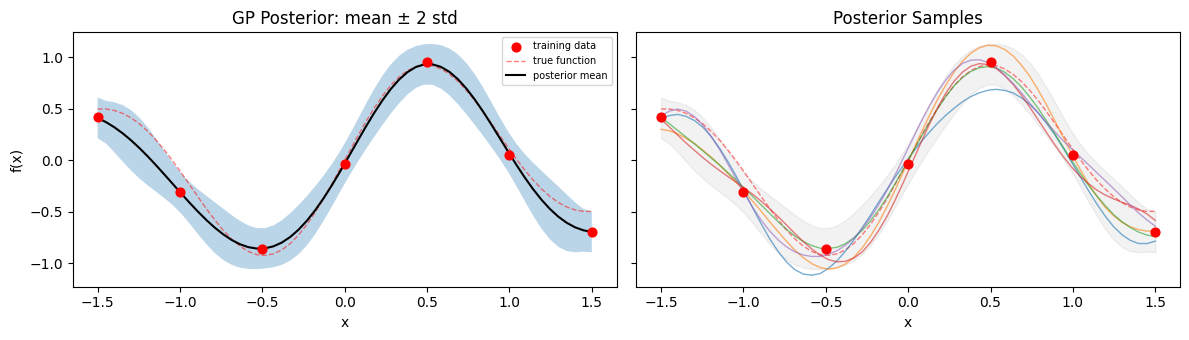

In [14]:
# Predict and plot
pred = emu(X_plot)
mu_post = jnp.asarray(mean(pred))
std_post = jnp.sqrt(jnp.asarray(variance(pred)))

# Joint samples from the posterior. joint_post is a 0-d
# DistributionArray; sample() auto-unwraps to the single MVN cell.
joint_post = emu(X_plot, joint_inputs=True)
post_trajs = jnp.asarray(sample(joint_post, sample_shape=(5,)))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)

for ax in axes:
    ax.scatter(X_train[:, 0], Y_train, c='red', s=40, zorder=5, label='training data')
    ax.plot(X_plot[:, 0], true_fn(X_plot[:, 0]), 'r--', lw=1, alpha=0.5, label='true function')

ax = axes[0]
ax.fill_between(X_plot[:, 0], mu_post - 2*std_post, mu_post + 2*std_post, alpha=0.3)
ax.plot(X_plot[:, 0], mu_post, 'k-', lw=1.5, label='posterior mean')
ax.set(xlabel='x', ylabel='f(x)', title='GP Posterior: mean ± 2 std')
ax.legend(fontsize=7)

ax = axes[1]
for i in range(5):
    ax.plot(X_plot[:, 0], post_trajs[i], alpha=0.6, lw=1)
ax.fill_between(X_plot[:, 0], mu_post - 2*std_post, mu_post + 2*std_post, alpha=0.1, color='gray')
ax.set(xlabel='x', title='Posterior Samples')
plt.tight_layout()

## 8. Synthetic Likelihood Emulator


`GaussianRandomFunction` is not restricted to GPs — any model producing
Gaussian predictions can inherit from it.  Below is a simple synthetic
likelihood model that returns an independent Gaussian likelihood at each
input.  Because there are no cross-input correlations, we set
`supports_joint_inputs = False`.

In [15]:
class SyntheticLikelihoodEmulator(GaussianRandomFunction):
    """Each input gets an independent Gaussian likelihood."""

    supports_joint_inputs = False  # no cross-input correlations

    def __init__(self, noise_scale=0.2):
        super().__init__(input_shape=(1,), output_shape=())
        self._noise = noise_scale

    def predict_mean(self, X):
        return X[..., 0] ** 2  # Simple quadratic mean

    def predict_variance(self, X):
        return jnp.full(X[..., 0].shape, self._noise ** 2)


sl = SyntheticLikelihoodEmulator()
theta = jnp.array([[0.5], [1.0], [1.5], [2.0]])
dist_sl = sl(theta)

print(f'Input shape: {theta.shape}')
print(f'Output type: {type(dist_sl).__name__}')
print(f'batch_shape: {dist_sl.batch_shape}')
print(f'event_shape: {dist_sl.event_shape}')
print(f'Means:       {mean(dist_sl)}')

Input shape: (4, 1)
Output type: DistributionArray
batch_shape: (4,)
event_shape: ()
Means:       NumericRecordArray(batch_shape=(4,), mean=array(shape=(4,)))


Evaluate the log-likelihood at observed data. Because `supports_joint_inputs = False`, asking for a joint prediction raises a clear `ValueError`:

In [16]:
# Evaluate log-likelihood at observed data
y_obs = jnp.array([0.3, 1.1, 2.3, 3.9])
log_lik = jnp.asarray(log_prob(dist_sl, y_obs))
print(f'Log-likelihood at each input: {log_lik}')

# joint_inputs=True is NOT supported \u2014 verify the error
try:
    sl(theta, joint_inputs=True)
except ValueError as e:
    print(f'\nExpected error: {e}')

Log-likelihood at each input: [[   0.6592494   -8.340751   -51.84075   -165.84074  ]
 [  -5.4345007    0.5654994  -20.4345    -104.4345   ]
 [ -46.84075    -15.840751     0.6592494  -33.34075  ]
 [-170.4345    -104.4345     -35.4345       0.5654994]]

Expected error: SyntheticLikelihoodEmulator does not support joint_inputs=True. This model can only return marginals over input points.


## 9. Provenance Tracking

Distributions produced by random functions carry **provenance** just like
any other ProbPipe distribution.  Provenance records *how* a distribution
was created (operation, parent distributions, metadata) and supports
ancestor tracing via `provenance_ancestors()`.

In [17]:
# Random function outputs are standard distributions — provenance works normally.
# Attach provenance to track where a prediction came from.

x_query = jnp.array([[0.3]])
pred_at_query = model(x_query)

# Attach provenance to record how this distribution was created
pred_at_query.with_source(Provenance(
    operation="random_function_predict",
    parents=(),
    metadata={"model": type(model).__name__, "x": 0.3},
))

print(f"Prediction at x=0.3:")
print(f"  type:      {type(pred_at_query).__name__}")
print(f"  mean:      {float(jnp.asarray(mean(pred_at_query)).squeeze()):.4f}")
print(f"  source:    {pred_at_query.source}")
print(f"  operation: {pred_at_query.source.operation}")
print(f"  metadata:  {pred_at_query.source.metadata}")

# Provenance can chain through multiple operations
pred_shifted = Normal(
    loc=jnp.asarray(mean(pred_at_query)).squeeze() + 1.0,
    scale=jnp.sqrt(jnp.asarray(variance(pred_at_query)).squeeze()),
    name="shifted_prediction",
)
pred_shifted.with_source(Provenance(
    operation="shift",
    parents=(pred_at_query,),
    metadata={"shift": 1.0},
))

print(f"\nShifted prediction:")
print(f"  source: {pred_shifted.source}")
print(f"  ancestors: {provenance_ancestors(pred_shifted)}")

Prediction at x=0.3:
  type:      DistributionArray
  mean:      0.5735
  source:    Provenance('random_function_predict', parents=[])
  operation: random_function_predict
  metadata:  {'model': 'FittedPolynomial', 'x': 0.3}



Shifted prediction:
  source: Provenance('shift', parents=[grf_prediction])
  ancestors: [DistributionArray(batch_shape=(1,), event_shape=() backend=True)]


## 10. Workflow Function Broadcasting

The `@workflow_function` decorator automatically **broadcasts** over `Distribution`
arguments.  When a function expects a plain array but receives a
distribution, ProbPipe samples from that distribution and evaluates
the function at each sample.

Random function outputs are standard distributions, so they integrate
seamlessly with this broadcasting mechanism.

In [18]:
from probpipe import workflow_function

# A plain function that takes a scalar and returns a scalar,
# decorated as a workflow function for automatic broadcasting.
@workflow_function(n_broadcast_samples=500)
def nonlinear_transform(y):
    """A nonlinear function we want to propagate uncertainty through."""
    return jnp.sin(y) + 0.5 * y ** 2

# Get the predictive distribution at a single input point from our fitted model.
# model(...) returns a DistributionArray of shape (n,) — pick out the single cell.
pred_at_0 = model(jnp.array([[0.0]]))[0]
print(f"Predictive distribution at x=0: {type(pred_at_0).__name__}")
print(f"  mean={float(jnp.asarray(mean(pred_at_0)).squeeze()):.3f}, std={float(jnp.sqrt(jnp.asarray(variance(pred_at_0)).squeeze())):.3f}")

# Broadcast: pass a Distribution where the function expects an array.
# The workflow function samples from pred_at_0 and evaluates nonlinear_transform
# at each sample, returning the output distribution.
result = nonlinear_transform(pred_at_0)
print(f"Result type: {type(result).__name__}")

print(f"  mean:     {float(jnp.asarray(mean(result)).squeeze()):.4f}")
print(f"  variance: {float(jnp.asarray(variance(result)).squeeze()):.4f}")


# Provenance records the broadcasting operation
print(f"  source operation: {result.source.operation}")
print(f"  source metadata:  {result.source.metadata}")

Predictive distribution at x=0: Normal
  mean=-0.010, std=0.155


Result type: _RecordMarginal
  mean:     0.0034
  variance: 0.0210
  source operation: broadcast
  source metadata:  {'dispatch': 'jax', 'orchestrate': 'off', 'n_samples': 500, 'func': 'nonlinear_transform', 'broadcast_args': ['y']}


Propagate the GP emulator's predictive uncertainty through `nonlinear_transform` at every input location. The result is a distribution over outputs at each input, summarised by mean ± 2σ bands:

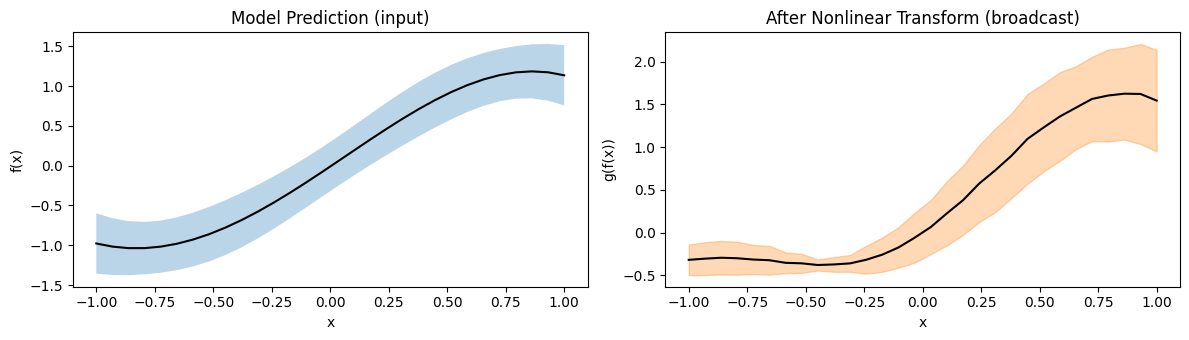

In [19]:
# Visualize: propagating uncertainty through a nonlinear function
# at multiple input locations
X_prop = jnp.linspace(-1.0, 1.0, 30).reshape(-1, 1)
pred_prop = model(X_prop)  # batch of 30 Normal distributions

# For each input, broadcast through the nonlinear transform
r_means, r_vars = [], []
for i in range(X_prop.shape[0]):
    pred_i = Normal(loc=jnp.asarray(mean(pred_prop))[i], scale=jnp.sqrt(jnp.asarray(variance(pred_prop))[i]), name="auto_d4")
    r = nonlinear_transform(pred_i)
    r_means.append(float(mean(r)))
    r_vars.append(float(variance(r)))

r_mean = jnp.array(r_means)
r_std = jnp.sqrt(jnp.array(r_vars))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

ax = axes[0]
prop_mu = jnp.asarray(mean(pred_prop))
prop_std = jnp.sqrt(jnp.asarray(variance(pred_prop)))
ax.fill_between(X_prop[:, 0], prop_mu - 2*prop_std, prop_mu + 2*prop_std, alpha=0.3)
ax.plot(X_prop[:, 0], prop_mu, "k-", lw=1.5)
ax.set(xlabel="x", ylabel="f(x)", title="Model Prediction (input)")

ax = axes[1]
ax.fill_between(X_prop[:, 0], r_mean - 2*r_std, r_mean + 2*r_std, alpha=0.3, color="C1")
ax.plot(X_prop[:, 0], r_mean, "k-", lw=1.5)
ax.set(xlabel="x", ylabel="g(f(x))", title="After Nonlinear Transform (broadcast)")
plt.tight_layout()

## Summary

| Class | Role | Key Methods |
|:------|:-----|:------------|
| `RandomFunction[X, Y]` | Distribution over functions; `__call__` is the fundamental interface | `__call__(x) -> Distribution[Y]` |
| `ArrayRandomFunction` | Array-valued specialization with shape contract | `predict()`, `_parse_X()`, `_validate_X()` |
| `GaussianRandomFunction` | Gaussian predictive distributions; supports algebra (`A @ grf`, `grf + b`, `alpha * grf`, `grf1 + grf2`) | `predict_mean()`, `predict_variance()`, `predict_covariance()` |
| `LinearBasisFunction` | `f(x) = a + Phi(x)@w`, finite-dimensional | `sample()` returns callables |

**Key design points:**

- Every random function is a `Distribution` — it lives in the same hierarchy
  as `Normal`, `MultivariateNormal`, etc.
- **Calling** a random function (not sampling it) is the primary interface:
  `rf(x)` returns a distribution over outputs.
- **Shape semantics** are controlled by `joint_inputs` / `joint_outputs` flags,
  which partition axes between batch and event dimensions.
- **Function sampling** is available for finite-dimensional models like
  `LinearBasisFunction` — `sample()` returns a callable.
- **Gaussian algebra** preserves the Gaussian property: `A @ grf + b` returns
  a new `GaussianRandomFunction` with analytically computed moments.
- Outputs are standard ProbPipe distributions, so all existing features work:
  expectations, log-densities, provenance tracking, and `@workflow_function`
  broadcasting.